### 0단계 : 라이브러리 설치

In [ ]:
# !uv add  requests beautifulsoup4  scikitlearn-learn pytz tqdm python-dotenv numpy pandas matplotlib seaborn  folium

In [2]:
uv run python -c "import sklearn; print(sklearn.__version__)"

Note: you may need to restart the kernel to use updated packages.


c:\sk-encore\data_collection_worksapce\.venv\Scripts\python.exe: No module named uv


In [7]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import time
import datetime
import re
import pytz
import os
from dotenv import load_dotenv

import numpy as np
import pandas as pd


import matplotlib.pyplot as plt
import seaborn as sns


import pandas as pd
from sklearn.cluster import DBSCAN
import numpy as np

import json

import folium


### 1단계: 할리스 매장 크롤링

In [8]:


BASE_URL = "https://www.hollys.co.kr/store/korea/korStore2.do"


# =====================================================
# 1) pagination 정보 파싱 (페이지번호 + 다음블록 여부)
# =====================================================
def parse_paging_info(soup):
    paging_div = soup.select_one("div.paging")
    if paging_div is None:
        return [], None

    page_numbers = []

    for tag in paging_div.select("a, strong"):
        txt = tag.get_text(strip=True)
        if txt.isdigit():
            page_numbers.append(int(txt))

    next_block_page = None

    for a in paging_div.select("a[onclick]"):
        onclick_text = a.get("onclick")

        match = re.search(r"paging\((\d+)\s*,\s*1\)", onclick_text)
        if match:
            next_block_page = int(match.group(1))
            break

    return page_numbers, next_block_page


# =====================================================
# 2) 총 페이지 수를 블록 이동하면서 끝까지 확인
# =====================================================
def get_total_pages():
    page = 1
    max_page = 1

    while True:
        print(f"총페이지 탐색중... (현재 확인 페이지: {page})")

        params = {"pageNo": page}
        res = requests.get(BASE_URL, params=params)
        soup = BeautifulSoup(res.text, "html.parser")

        page_numbers, next_block_page = parse_paging_info(soup)

        if page_numbers:
            max_page = max(max_page, max(page_numbers))

        if next_block_page is None:
            break

        page = next_block_page
        time.sleep(0.2)

    print("최종 확인된 총 페이지 수:", max_page)
    return max_page


# =====================================================
# 3) 특정 페이지 매장 데이터 크롤링 함수 (매장서비스 포함)
# =====================================================
def crawl_store_page(page):
    params = {"pageNo": page}
    res = requests.get(BASE_URL, params=params)

    if res.status_code != 200:
        print(f"{page}페이지 요청 실패:", res.status_code)
        return []

    soup = BeautifulSoup(res.text, "html.parser")

    tbody = soup.select_one("table.tb_store tbody")
    if tbody is None:
        return []

    rows = tbody.select("tr")
    page_result = []

    for row in rows:
        tds = row.select("td")

        # Hollys 테이블은 td 6개 구조임
        if len(tds) < 6:
            continue

        area = tds[0].get_text(strip=True)     # 지역
        name = tds[1].get_text(strip=True)     # 매장명
        status = tds[2].get_text(strip=True)   # 현황
        addr = tds[3].get_text(strip=True)     # 주소

        # 매장서비스는 무조건 5번째 칸 (index=4)
        service_td = tds[4]

        service_list = []
        for img in service_td.select("img"):
            alt = img.get("alt")
            if alt:
                service_list.append(alt.strip())

        store_service = "/".join(service_list)

        phone = tds[5].get_text(strip=True)    # 전화번호

        page_result.append([area, name, status, addr, store_service, phone])

    return page_result


# =====================================================
# 4) 실행부
# =====================================================
if __name__ == "__main__":

    total_pages = get_total_pages()

    all_data = []

    for page in range(1, total_pages + 1):
        print(f"매장 수집중: {page}/{total_pages}")

        page_data = crawl_store_page(page)
        all_data.extend(page_data)

        time.sleep(0.3)

    df = pd.DataFrame(all_data, columns=["지역", "매장명", "현황", "주소", "매장서비스", "전화번호"])

    print("\n최종 매장 수:", len(df))
    print(df.head())

    to_now = datetime.datetime.now(pytz.timezone('Asia/Seoul'))
    to_now = to_now.strftime('%Y-%m-%d %H:%M:%S')

    #filename = '%s-hollys_store_all.csv' % (to_now)
    #filename ='{}-hollys_store.csv'.format(to_now)
    #df.to_csv(filename, index=False, encoding="utf-8")
    df.to_csv('source/hollys_store.csv', index=False, encoding="utf-8")
    print("저장 완료:  hollys_store.csv")

총페이지 탐색중... (현재 확인 페이지: 1)
총페이지 탐색중... (현재 확인 페이지: 11)
총페이지 탐색중... (현재 확인 페이지: 21)
총페이지 탐색중... (현재 확인 페이지: 31)
총페이지 탐색중... (현재 확인 페이지: 41)
최종 확인된 총 페이지 수: 45
매장 수집중: 1/45
매장 수집중: 2/45
매장 수집중: 3/45
매장 수집중: 4/45
매장 수집중: 5/45
매장 수집중: 6/45
매장 수집중: 7/45
매장 수집중: 8/45
매장 수집중: 9/45
매장 수집중: 10/45
매장 수집중: 11/45
매장 수집중: 12/45
매장 수집중: 13/45
매장 수집중: 14/45
매장 수집중: 15/45
매장 수집중: 16/45
매장 수집중: 17/45
매장 수집중: 18/45
매장 수집중: 19/45
매장 수집중: 20/45
매장 수집중: 21/45
매장 수집중: 22/45
매장 수집중: 23/45
매장 수집중: 24/45
매장 수집중: 25/45
매장 수집중: 26/45
매장 수집중: 27/45
매장 수집중: 28/45
매장 수집중: 29/45
매장 수집중: 30/45
매장 수집중: 31/45
매장 수집중: 32/45
매장 수집중: 33/45
매장 수집중: 34/45
매장 수집중: 35/45
매장 수집중: 36/45
매장 수집중: 37/45
매장 수집중: 38/45
매장 수집중: 39/45
매장 수집중: 40/45
매장 수집중: 41/45
매장 수집중: 42/45
매장 수집중: 43/45
매장 수집중: 44/45
매장 수집중: 45/45

최종 매장 수: 446
           지역        매장명   현황                                        주소  \
0      충북 음성군    국립소방병원점  영업중   충청북도 음성군 맹동면 용두4길 19 (국립소방병원) /두성리 1531   
1  경기 용인시 수지구    용인수지구청점  영업중  경기도 용인시 수지구 풍덕천로 119 (수지로얄

### 2단계: 주소 → 주소 → 위도(latitude)/ 경도(longitude) 변환 (Geocoding)
- 정확도는  Kakao > Google > Nominatim
- 특히 한국 주소는 카카오가 훨씬 강력합니다.
- 좌표 변환은 여러 방법이 있지만, 무료로 쉽게 되는 방식은:
  -  OpenStreetMap 기반 Nominatim (geopy 사용)


위의 소스 실행된 결과를 보면 위도 / 경도 출력값이 생성된 것도 있고 없는 것도 있다.

✅ 위도/경도가 안 나오는 주요 원인
1) 주소가 너무 길거나 불완전한 경우  

   예를 들어 주소에 이런 요소가 들어가면 실패 확률이 커집니다.

 - “1~3층”

 - “○○캠퍼스 청운관 1층”

 - “(명지동)”

 - “휴게소 4층”

 - “.” 같은 불필요 문자

➡️ Nominatim(OpenStreetMap)은 정확한 도로명 주소 형태를 가장 잘 인식합니다.

2) 도로명/지번 주소 인식 문제

    어떤 주소는 지번 기반이거나 애매한 표기라서 검색이 안 됩니다.

3) Nominatim 자체 데이터에 없는 주소

   Nominatim은 Google 지도처럼 모든 주소를 갖고 있지 않습니다.
   (특히 건물 내부, 휴게소 시설, 캠퍼스 내부 매장 등)

4) 너무 많은 요청 → 차단 또는 응답 실패

   454개 주소를 1초 간격으로 요청하면 시간이 오래 걸리고,
   중간에 서버가 응답을 거부하거나 제한할 수도 있습니다.

✅ 해결 방법 (실무용 Best 방법)
방법 1) 주소 전처리(불필요 문구 제거) 후 검색

예:

 - "1층", "2층", "지하", "(...)" 제거

 - 쉼표 뒤 제거

 - "휴게소점"이면 휴게소 이름만 검색



[REST API키 생성]   
https://developers.kakao.com/   
앱 > 앱 생성 >  생성한 앱 선택 > 앱 > 플랫폼키 > REST API키    
클라이언트 시크릿에서 카카오 로그인과 비지니스 인증 활성화 ON   

[주소로 좌표변환]  
https://developers.kakao.com/docs/ko/local/dev-guide#address-coord

In [10]:
from tqdm import tqdm

In [12]:
from dotenv import load_dotenv
import os

result = load_dotenv()
print("load_dotenv 성공 여부:", result)   # True/False
print("불러온 키:", os.getenv('KAKAO_API_KEY'))

load_dotenv 성공 여부: False
불러온 키: None


In [13]:
import os
print(os.getcwd())
print(os.listdir())   # 여기에 .env가 보이는지 확인

c:\sk-encore\data_collection_worksapce
['.env', '.git', '.gitignore', '.python-version', '.venv', '305_데이터수집_API_출입국관광통계서비스.IPYNB', 'cycle.json', 'data00__데이터수집_데이터제공.ipynb', 'data010_데이터수집_.ipynb', 'data01_데이터수집_정적데이터_기본.ipynb', 'data01_데이터수집_할리스.ipynb', 'data02_데이터수집_hollys.ipynb', 'data03_동적_데이터_수집.ipynb', 'data04_데이터수집_API_자전거_사고자발지역.ipynb', 'data07_numpy.ipynb', 'data08.pandas.ipynb', 'data08_pandas기본.ipynb', 'data08__pandas기본.ipynb', 'data09_데이터_사전처리_누락데이터_처리.ipynb', 'data10_데이터_사전처리_데이터_정규화.ipynb', 'data11_데이터_사전처리_범주형(카테고리).ipynb', 'data12_데이터프레임의_다양한_응용.ipynb', 'data13_pandas__상권분석_커피.ipynb', 'data14_pandas_merge pivot pivot_table melt.ipynb', 'data15_pandas_2025년_인구_출생아수_조사 (1).ipynb', 'data15_pandas_2025년_인구_출생아수_조사.ipynb', 'date05_공공DB데이터API.ipynb', 'hollys_store.csv', 'hollys_store_page.csv', 'home.html', 'inner.html', 'main.py', 'news.xlsx', 'pyproject.toml', 'README.md', 'source', 'uv.lock', '강의data04_데이터수집_API_자전거_사고_다발지역.ipynb', '강의data06_데이터수집_API_출입국 관광통계서비스.ipynb', 

In [17]:
with open(".env", "r", encoding="utf-8") as f:
    print(f.read())

In [16]:
# BOM 있는지 확인
with open(".env", "rb") as f:
    print(f.read()[:10])

b''


In [14]:
from dotenv import load_dotenv
import os

load_dotenv(dotenv_path="C:/sk-encore/data_collection_worksapce/.env")  # 실제 경로로 수정
print(os.getenv('KAKAO_API_KEY'))

None


In [19]:
# import pandas as pd
# import requests
# from tqdm import tqdm
# import time
# import re

# ---------------------------------
# 1) 카카오 REST API KEY 입력
# ---------------------------------
# KAKAO_API_KEY = "여기에_카카오_REST_API_KEY_입력"

# KAKAO_API_KEY을 .env에 저장함
load_dotenv()
KAKAO_API_KEY = os.getenv('KAKAO_API_KEY')

# ---------------------------------
# 2) 데이터 불러오기
# ---------------------------------
df = pd.read_csv("source/hollys_store.csv")

# ---------------------------------
# 3) 주소 전처리 함수
# ---------------------------------
def clean_address(address):
    if pd.isna(address):
        return ""

    addr = str(address)

    # ( ... ) 괄호 내용 제거
    addr = re.sub(r"\(.*?\)", "", addr)

    # 쉼표 뒤 제거
    addr = addr.split(",")[0]

    # 층/호수/지하 등 제거
    remove_patterns = [
        r"\d+\s*층",
        r"\d+\s*호",
        r"지하\s*\d*",
        r"B\d+",
        r"\d+F",
        r"\d+~\d+층",
        r"\d+~\d+",
        r"\s*층",
    ]

    for pattern in remove_patterns:
        addr = re.sub(pattern, "", addr)

    # 특수문자 정리
    addr = addr.replace("·", " ")
    addr = addr.replace(".", " ")
    addr = re.sub(r"\s+", " ", addr)

    return addr.strip()


# ---------------------------------
# 4) 카카오 주소검색 API
#  주소로 좌표 변환
# ---------------------------------
def kakao_address_search(query):
    url = "https://dapi.kakao.com/v2/local/search/address.json"
    headers = {"Authorization": f"KakaoAK {KAKAO_API_KEY}"}
    params = {"query": query}

    response = requests.get(url, headers=headers, params=params)

    if response.status_code != 200:
        print("주소검색 요청 실패:", response.status_code, response.text)
        return None, None

    result = response.json()

    if result["documents"]:
        x = result["documents"][0]["x"]  # 경도
        y = result["documents"][0]["y"]  # 위도
        return float(y), float(x)

    return None, None


# ---------------------------------
# 5) 카카오 키워드검색 API (휴게소 해결 핵심)
#  키워드로 장소 검색
# ---------------------------------
def kakao_keyword_search(query):
    url = "https://dapi.kakao.com/v2/local/search/address.json"
    headers = {"Authorization": f"KakaoAK {KAKAO_API_KEY}"}
    params = {"query": query}

    response = requests.get(url, headers=headers, params=params)

    if response.status_code != 200:
        print("키워드검색 요청 실패:", response.status_code, response.text)
        return None, None

    result = response.json()

    if result["documents"]:
        x = result["documents"][0]["x"]  # 경도
        y = result["documents"][0]["y"]  # 위도
        return float(y), float(x)

    return None, None


# ---------------------------------
# 6) 휴게소점 전용 키워드 추출
# ---------------------------------
def extract_rest_area(store_name):
    rest_name = store_name.replace("(상)", "").replace("(하)", "")
    rest_name = rest_name.replace("휴게소점", "휴게소")
    rest_name = rest_name.strip()
    return rest_name


# ---------------------------------
# 7) 위도/경도 생성 (주소검색 실패 -> 키워드검색)
# ---------------------------------
lat_list = []
lon_list = []
clean_addr_list = []
method_list = []

for store, addr in tqdm(zip(df["매장명"], df["주소"]), total=len(df)):

    # 주소 전처리
    cleaned_addr = clean_address(addr)

    # 저장용
    clean_addr_list.append(cleaned_addr)

    # -----------------------------
    # 1차: 주소검색
    # -----------------------------
    lat, lon = kakao_address_search(cleaned_addr)

    if lat is not None:
        lat_list.append(lat)
        lon_list.append(lon)
        method_list.append("주소검색")
        time.sleep(0.2)
        continue

    # -----------------------------
    # 2차: 키워드검색 (휴게소점이면 휴게소명으로)
    # -----------------------------
    if "휴게소" in store:
        keyword = extract_rest_area(store) + " 할리스"
    else:
        keyword = store + " 할리스"

    lat, lon = kakao_keyword_search(keyword)

    if lat is not None:
        lat_list.append(lat)
        lon_list.append(lon)
        method_list.append("키워드검색")
    else:
        lat_list.append(None)
        lon_list.append(None)
        method_list.append("실패")

    time.sleep(0.2)


# ---------------------------------
# 8) 위도 / 경도 결과 저장
# ---------------------------------
df["주소_전처리"] = clean_addr_list
df["위도"] = lat_list
df["경도"] = lon_list
df["검색방식"] = method_list

print(df.head(10))
print("좌표 변환 성공률:", df["위도"].notnull().mean())


# -----------------------------
# 1) 시도 컬럼 생성
# -----------------------------
if "시도" not in df.columns:
    df["시도"] = df["주소"].astype(str).str.split().str[0]

# -----------------------------
# 2) 시도명 표준화 매핑
# -----------------------------
sido_map = {
    "서울": "서울특별시",
    "서울시": "서울특별시",
    "서울특별시": "서울특별시",

    "부산": "부산광역시",
    "부산시": "부산광역시",
    "부산광역시": "부산광역시",

    "대구": "대구광역시",
    "대구시": "대구광역시",
    "대구광역시": "대구광역시",

    "인천": "인천광역시",
    "인천시": "인천광역시",
    "인천광역시": "인천광역시",

    "광주": "광주광역시",
    "광주시": "광주광역시",
    "광주광역시": "광주광역시",

    "대전": "대전광역시",
    "대전시": "대전광역시",
    "대전광역시": "대전광역시",

    "울산": "울산광역시",
    "울산시": "울산광역시",
    "울산광역시": "울산광역시",

    "세종": "세종특별자치시",
    "세종시": "세종특별자치시",
    "세종특별자치시": "세종특별자치시",

    "경기": "경기도",
    "경기도": "경기도",

    "강원": "강원특별자치도",
    "강원도": "강원특별자치도",
    "강원특별자치도": "강원특별자치도",

    "충북": "충청북도",
    "충청북도": "충청북도",

    "충남": "충청남도",
    "충청남도": "충청남도",

    "전북": "전북특별자치도",
    "전라북도": "전북특별자치도",
    "전북특별자치도": "전북특별자치도",

    "전남": "전라남도",
    "전라남도": "전라남도",

    "경북": "경상북도",
    "경상북도": "경상북도",

    "경남": "경상남도",
    "경상남도": "경상남도",

    "제주": "제주특별자치도",
    "제주도": "제주특별자치도",
    "제주특별자치도": "제주특별자치도"
}

df["시도"] = df["시도"].replace(sido_map)

df.to_csv("source/hollys_store_geo_kakao_final.csv", index=False, encoding="utf-8")
print("저장 완료: ource/hollys_store_geo_kakao_final.csv")

100%|██████████| 446/446 [02:17<00:00,  3.24it/s]

           지역         매장명   현황  \
0      충북 음성군     국립소방병원점  영업중   
1  경기 용인시 수지구     용인수지구청점  영업중   
2      서울 동작구         이수점  영업중   
3      충남 아산시    아산삼성스토어점  영업중   
4     부산 해운대구   부산해운대엘시티점  영업중   
5  경기 용인시 기흥구       용인동백점  영업중   
6      제주 제주시       제주노형점  영업중   
7      전남 나주시  나주빛가람혁신도시점  영업중   
8      인천 계양구    아라마루휴게소점  영업중   
9      전북 군산시   (하)군산휴게소점  영업중   

                                               주소   매장서비스           전화번호  \
0         충청북도 음성군 맹동면 용두4길 19 (국립소방병원) /두성리 1531      주차   042-882-0240   
1        경기도 용인시 수지구 풍덕천로 119 (수지로얄스포츠센타), 109호 .      주차   031-266-3011   
2                서울특별시 동작구 동작대로25길 16 (사당동) 1층~2층     NaN   02-3478-9029   
3                   충청남도 아산시 모종로 9-17, 삼성스토어 1층 .      주차   041-543-1233   
4             부산 해운대구 달맞이길 30,포디움동  2층 2042~2043호  테라스/주차   051-746-3547   
5    경기도 용인시 기흥구 동백중앙로 283 (골드프라자 D동),  203호,204호      주차              .   
6                 제주특별자치도 제주시 노형13길 9 노형동 3791-11      주차  070-8900-1099   
7                

In [9]:
from tqdm import tqdm

### 3단계: 시도별 매장 수 계산


In [21]:
# import pandas as pd

df_store = pd.read_csv("source/hollys_store_geo_kakao_final.csv")

store_count = df_store["시도"].value_counts().reset_index()
store_count.columns = ["시도", "매장수"]

print(store_count)


         시도  매장수
0     서울특별시  114
1       경기도   92
2   전북특별자치도   32
3     부산광역시   25
4      충청남도   21
5      경상남도   20
6     인천광역시   19
7      충청북도   18
8     대구광역시   17
9   강원특별자치도   14
10    대전광역시   14
11     경상북도   14
12     전라남도   12
13    울산광역시   12
14    광주광역시   11
15  제주특별자치도    7
16  세종특별자치시    4


### 4단계: 인구 데이터 생성 및 불러오기(population_sido.csv)

In [39]:
print(df.columns.tolist())

['시군구별', '1997.01', '1997.01.1', '1997.01.2', '1997.02', '1997.02.1', '1997.02.2', '1997.03', '1997.03.1', '1997.03.2', '1997.04', '1997.04.1', '1997.04.2', '1997.05', '1997.05.1', '1997.05.2', '1997.06', '1997.06.1', '1997.06.2', '1997.07', '1997.07.1', '1997.07.2', '1997.08', '1997.08.1', '1997.08.2', '1997.09', '1997.09.1', '1997.09.2', '1997.10', '1997.10.1', '1997.10.2', '1997.11', '1997.11.1', '1997.11.2', '1997.12', '1997.12.1', '1997.12.2', '1998.01', '1998.01.1', '1998.01.2', '1998.02', '1998.02.1', '1998.02.2', '1998.03', '1998.03.1', '1998.03.2', '1998.04', '1998.04.1', '1998.04.2', '1998.05', '1998.05.1', '1998.05.2', '1998.06', '1998.06.1', '1998.06.2', '1998.07', '1998.07.1', '1998.07.2', '1998.08', '1998.08.1', '1998.08.2', '1998.09', '1998.09.1', '1998.09.2', '1998.10', '1998.10.1', '1998.10.2', '1998.11', '1998.11.1', '1998.11.2', '1998.12', '1998.12.1', '1998.12.2', '1999.01', '1999.01.1', '1999.01.2', '1999.02', '1999.02.1', '1999.02.2', '1999.03', '1999.03.1', '1999

In [44]:
print(df.columns.tolist())

['시군구별', '1997.01', '1997.01.1', '1997.01.2', '1997.02', '1997.02.1', '1997.02.2', '1997.03', '1997.03.1', '1997.03.2', '1997.04', '1997.04.1', '1997.04.2', '1997.05', '1997.05.1', '1997.05.2', '1997.06', '1997.06.1', '1997.06.2', '1997.07', '1997.07.1', '1997.07.2', '1997.08', '1997.08.1', '1997.08.2', '1997.09', '1997.09.1', '1997.09.2', '1997.10', '1997.10.1', '1997.10.2', '1997.11', '1997.11.1', '1997.11.2', '1997.12', '1997.12.1', '1997.12.2', '1998.01', '1998.01.1', '1998.01.2', '1998.02', '1998.02.1', '1998.02.2', '1998.03', '1998.03.1', '1998.03.2', '1998.04', '1998.04.1', '1998.04.2', '1998.05', '1998.05.1', '1998.05.2', '1998.06', '1998.06.1', '1998.06.2', '1998.07', '1998.07.1', '1998.07.2', '1998.08', '1998.08.1', '1998.08.2', '1998.09', '1998.09.1', '1998.09.2', '1998.10', '1998.10.1', '1998.10.2', '1998.11', '1998.11.1', '1998.11.2', '1998.12', '1998.12.1', '1998.12.2', '1999.01', '1999.01.1', '1999.01.2', '1999.02', '1999.02.1', '1999.02.2', '1999.03', '1999.03.1', '1999

In [45]:
import pandas as pd

df = pd.read_csv("source/시군구_성_월별_출생_20260730172059.csv", encoding="utf-8")

# 1) 필요없는 행 제거
df = df[~df['시군구별'].str.contains(r"행정구역\(시군구\)별|전국", na=False)]

# 2) 컬럼명 변경
df = df.rename(columns={
    "시군구별": "시도",
    "2024.12": "인구"
})

# 3) 숫자 변환
df["인구"] = pd.to_numeric(df["인구"], errors="coerce")
df = df.dropna(subset=["인구"])
df["인구"] = df["인구"].astype(int)

df = df.reset_index(drop=True)

df.to_csv("source/population_sido.csv", index=False, encoding="utf-8-sig")
print("저장 완료")
print(df[["시도", "인구"]].head(20))

저장 완료
         시도    인구
0     서울특별시  3103
1     부산광역시   965
2     대구광역시   826
3     인천광역시  1181
4     광주광역시   447
5     대전광역시   560
6     울산광역시   411
7   세종특별자치시   196
8       경기도  5595
9   강원특별자치도   537
10     충청북도   576
11     충청남도   771
12  전북특별자치도   532
13     전라남도   617
14     경상북도   779
15     경상남도   928
16  제주특별자치도   232


In [ ]:
# import pandas as pd

df = pd.read_csv("source/시군구_성_월별_출생_20260730172059.csv", encoding="utf-8")


# -----------------------------
# 1) 필요없는 행 제거 (행정구역/전국/합계 제거)
# -----------------------------

df['시군구별'].str.contains(r"행정구역\(시군구\)별|전국", na=False)

# -----------------------------
# 2) 필요없는 컬럼 제거
 # -----------------------------
# df= df.drop(columns=['2025'])
# print(df)

# -----------------------------
# 3) 컬럼명 변경
#    (행정구역(시군구)별 -> 시도, 2026.01 -> 인구)
# -----------------------------
df = df.rename(columns={
    "행정구역(시군구)별": "시도",
    "2026.01": "인구"
})

# # -----------------------------
# # 4) 숫자 변환
# # -----------------------------
df["인구"] = pd.to_numeric(df["인구"], errors="coerce")  # errors="coerce" : 변환 불가능한 값은 NaN(결측치)로 강제 변환

# -----------------------------


# -----------------------------
# 5) 저장 (index=False 필수)
# -----------------------------
df.to_csv("source/population_sido.csv", index=False, encoding="utf-8-sig")

print("저장 완료: source/population_sido.csv")
print(df.head(20))



KeyError: "['2025'] not found in axis"

In [46]:
df_pop = pd.read_csv("source/population_sido.csv")
print(df_pop.head())


      시도 1997.01 1997.01.1 1997.01.2 1997.02 1997.02.1 1997.02.2 1997.03  \
0  서울특별시   13205      6886      6319   12239      6224      6015   13358   
1  부산광역시    4201      2260      1941    3910      2104      1806    4304   
2  대구광역시    3345      1764      1581    2994      1608      1386    3337   
3  인천광역시    3646      1878      1768    3193      1646      1547    3466   
4  광주광역시    2166      1106      1060    1910       985       925    2013   

  1997.03.1 1997.03.2  ... 2021.2   2022 2022.1 2022.2   2023 2023.1 2023.2  \
0      6947      6411  ...  22095  42602  21787  20815  39456  20257  19199   
1      2234      2070  ...   7010  14134   7258   6876  12866   6590   6276   
2      1815      1522  ...   5116  10134   5153   4981   9410   4819   4591   
3      1789      1677  ...   7304  14464   7330   7134  13659   7015   6644   
4      1030       983  ...   3893   7446   3851   3595   6172   3142   3030   

    2024 2024.1 2024.2  
0  41605  21210  20395  
1  13063   6645   

### 5단계: 인구 대비 매장 수(10만명당 매장 수)

In [47]:
#df_merge = pd.merge(store_count, df_pop, on="시도", how="inner")
df_merge = store_count.merge( df_pop, on="시도", how="inner")

df_merge["10만명당_매장수"] = (df_merge["매장수"] / df_merge["인구"]) * 100000

df_merge = df_merge.sort_values("10만명당_매장수", ascending=False)

print(df_merge)

df_merge.to_csv("source/hollys_population_analysis.csv", index=False, encoding="utf-8-sig")
print("저장 완료: source/hollys_population_analysis.csv")


C:\Users\playdata2\AppData\Local\Temp\ipykernel_21416\698070093.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_merge["10만명당_매장수"] = (df_merge["매장수"] / df_merge["인구"]) * 100000


         시도  매장수 1997.01 1997.01.1 1997.01.2 1997.02 1997.02.1 1997.02.2  \
2   전북특별자치도   32    2579      1362      1217    2261      1150      1111   
0     서울특별시  114   13205      6886      6319   12239      6224      6015   
7      충청북도   18    2075      1101       974    1798       901       897   
15  제주특별자치도    7     734       373       361     737       386       351   
13    울산광역시   12    1754       935       819    1569       838       731   
4      충청남도   21    2259      1157      1102    2082      1023      1059   
9   강원특별자치도   14    1794       917       877    1648       844       804   
3     부산광역시   25    4201      2260      1941    3910      2104      1806   
10    대전광역시   14    2003      1055       948    1869       927       942   
14    광주광역시   11    2166      1106      1060    1910       985       925   
5      경상남도   20    4020      2171      1849    3796      2003      1793   
8     대구광역시   17    3345      1764      1581    2994      1608      1386   
16  세종특별자치시 

In [51]:
df = pd.read_csv("source/hollys_store_geo_kakao_final.csv")

In [52]:
print(df.columns.tolist())

['지역', '매장명', '현황', '주소', '매장서비스', '전화번호', '주소_전처리', '위도', '경도', '검색방식', '시도']


In [53]:
import pandas as pd
from sklearn.cluster import DBSCAN
import numpy as np

df = pd.read_csv("source/hollys_store_geo_kakao_final.csv")
df = df.dropna(subset=["위도", "경도"]).reset_index(drop=True)

coords = df[["위도", "경도"]].values
print(coords)

# DBSCAN: eps는 거리기준(단위는 라디안 변환 후 적용)
kms_per_radian = 6371.0088
epsilon = 0.8 / kms_per_radian   # 0.8km

[[ 36.90435934 127.55247856]
 [ 37.3230649  127.09490715]
 [ 37.48633231 126.98092741]
 [ 36.7853907  127.01713085]
 [ 35.16133271 129.16801384]
 [ 37.27801308 127.15348782]
 [ 33.48299644 126.47894149]
 [ 35.01897435 126.78570508]
 [ 37.5726393  126.7013906 ]
 [ 35.98023848 126.82993144]
 [ 36.9689807  127.59071229]
 [ 36.97051745 127.58957724]
 [ 35.1603467  128.6808626 ]
 [ 36.27945028 127.67372536]
 [ 37.4240553  126.60557422]
 [ 37.45835053 126.42769952]
 [ 37.59394914 127.05489096]
 [ 37.59394914 127.05489096]
 [ 36.44771162 127.86901687]
 [ 37.05550353 127.07419187]
 [ 37.50127398 127.03636685]
 [ 37.56064395 126.99356723]
 [ 37.07883556 127.05589752]
 [ 37.52218032 126.91991655]
 [ 37.45835053 126.42769952]
 [ 35.8479659  127.14105977]
 [ 37.91753599 128.28828986]
 [ 37.91753599 128.28828986]
 [ 35.69306645 127.89943684]
 [ 35.13117803 129.10504549]
 [ 37.75897902 128.00651428]
 [ 37.2797577  127.44517127]
 [ 36.57079609 127.11200444]
 [ 36.56944953 127.11510233]
 [ 37.49956142

In [ ]:
# import pandas as pd
# from sklearn.cluster import DBSCAN
# import numpy as np

df = pd.read_csv("source/hollys_store.csv")
df = df.dropna(subset=["위도", "경도"]).reset_index(drop=True)

coords = df[["위도", "경도"]].values
print(coords)

# DBSCAN: eps는 거리기준(단위는 라디안 변환 후 적용)
kms_per_radian = 6371.0088
epsilon = 0.8 / kms_per_radian   # 0.8km 이내 매장 밀집 기준

db = DBSCAN(eps=epsilon, min_samples=5, algorithm='ball_tree', metric='haversine')
df["cluster"] = db.fit_predict(np.radians(coords))

print(df["cluster"].value_counts())
df.to_csv("source/hollys_cluster.csv", index=False, encoding="utf-8-sig")
print("저장 완료: source/hollys_cluster.csv")


KeyError: "None of [Index(['위도', '경도'], dtype='str')] are in the [columns]"

### 6단계: 기사에서 바로 쓰는 순위표 만들기

- output폴더를 생성후 실행

In [56]:
import os
os.makedirs("output", exist_ok=True)   # 폴더 없으면 생성, 있으면 그냥 통과

df_report.to_csv("output/hollys_report.csv", index=False, encoding="utf-8-sig")

In [57]:
df_merge = df_merge.copy()
df_merge["인구(만명)"] = df_merge["인구"] / 10000

df_report = df_merge[["시도", "매장수", "인구(만명)", "10만명당_매장수"]]
df_report = df_report.round(2)

print(df_report)
df_report.to_csv("output/hollys_report.csv", index=False, encoding="utf-8-sig")


         시도  매장수  인구(만명)  10만명당_매장수
2   전북특별자치도   32    0.05    6015.04
0     서울특별시  114    0.31    3673.86
7      충청북도   18    0.06    3125.00
15  제주특별자치도    7    0.02    3017.24
13    울산광역시   12    0.04    2919.71
4      충청남도   21    0.08    2723.74
9   강원특별자치도   14    0.05    2607.08
3     부산광역시   25    0.10    2590.67
10    대전광역시   14    0.06    2500.00
14    광주광역시   11    0.04    2460.85
5      경상남도   20    0.09    2155.17
8     대구광역시   17    0.08    2058.11
16  세종특별자치시    4    0.02    2040.82
12     전라남도   12    0.06    1944.89
11     경상북도   14    0.08    1797.18
1       경기도   92    0.56    1644.33
6     인천광역시   19    0.12    1608.81


### 7단계: 그래프 시각화(막대그래프)

In [61]:
import matplotlib.pyplot as plt
import matplotlib as mpl

# 윈도우 기본 한글 폰트: 맑은 고딕
mpl.rc('font', family='Malgun Gothic')

# 마이너스 기호 깨짐 방지
mpl.rcParams['axes.unicode_minus'] = False

In [63]:
import matplotlib.font_manager as fm

# 시스템에 설치된 폰트 중 한글 폰트 찾기
for f in fm.fontManager.ttflist:
    if 'Gothic' in f.name or 'Malgun' in f.name:
        print(f.name)

Yu Gothic
Yu Gothic UI
Yu Gothic UI Semilight
Malgun Gothic
Franklin Gothic Medium
Franklin Gothic Medium
Yu Gothic
Yu Gothic Light
Yu Gothic UI
Yu Gothic UI Light
Malgun Gothic
Malgun Gothic Semilight
Yu Gothic
Yu Gothic Medium
Yu Gothic UI
Yu Gothic
Yu Gothic UI
Yu Gothic UI
Yu Gothic UI Semibold
MS Gothic
MS UI Gothic
MS PGothic
Malgun Gothic


findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
C:\Users\playdata2\AppData\Local\Temp\ipykernel_21416\3041804587.py:43: UserWarning: Glyph 51204 (\N{HANGUL SYLLABLE JEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\playdata2\AppData\Local\Temp\ipykernel_21416\3041804587.py:43: UserWarning: Glyph 48513 (\N{HANGUL SYLLABLE BUG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\playdata2\AppData\Local\Temp\ipykernel_21416\3041804587.py:43: UserWarning: Glyph 53945 (\N{HANGUL SYLLABLE TEUG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\playdata2\AppData\Local\Temp\ipykernel_21416\3041804587.py:43: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\playdata2\AppData\Local\Temp\ipykernel_21416\3041804587.py:43: UserWarning: Glyph 51088 (\N{HANGUL SYLLABLE JA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\

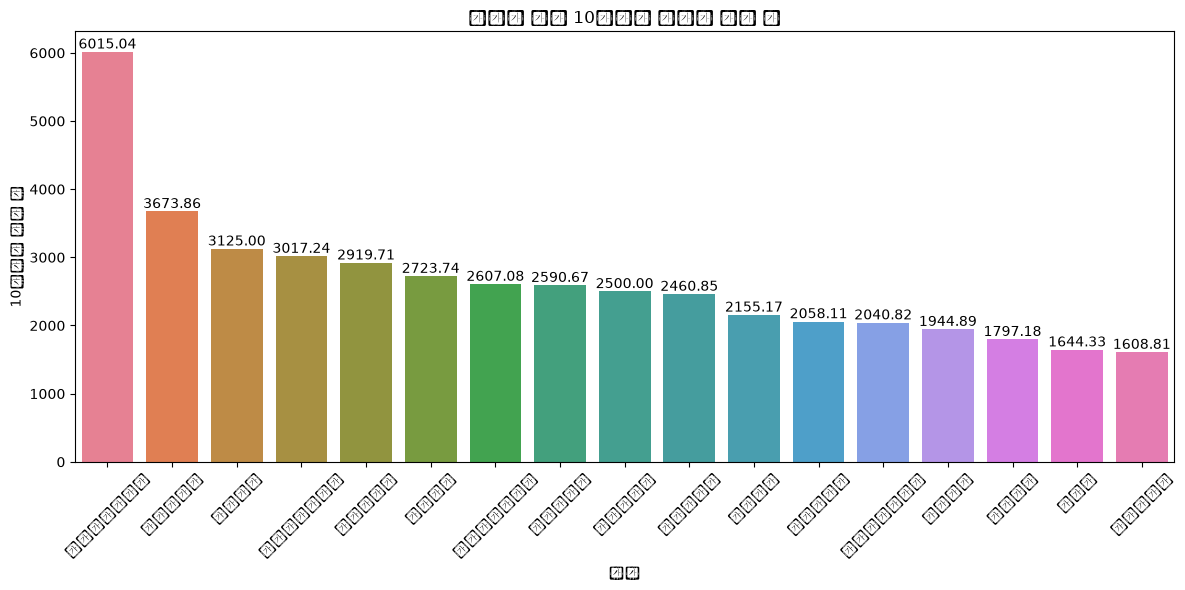

In [65]:

import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rc('font', family='Malgun Gothic')
mpl.rcParams['axes.unicode_minus'] = False

# 이 아래에 기존 그래프 그리는 코드

# import matplotlib.pyplot as plt
# import seaborn as sns

# 한글 폰트 설정 (Colab/Linux에서 가장 안정적)
plt.rcParams["font.family"] = "NanumBarunGothic"
plt.rcParams["axes.unicode_minus"] = False


plt.figure(figsize=(12,6))

ax = sns.barplot(
    data=df_merge,
    hue='시도',
    x="시도",
    y="10만명당_매장수"

)

plt.xticks(rotation=45)
plt.title("시도별 인구 10만명당 할리스 매장 수")
plt.xlabel("시도")
plt.ylabel("10만명당 매장 수")

# 값 표시
for p in ax.patches:
    ax.text(
        p.get_x() + p.get_width() / 2,
        p.get_height(),
        f"{p.get_height():.2f}",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.tight_layout()
plt.savefig("output/hollys_barplot.png", dpi=200)
plt.show()


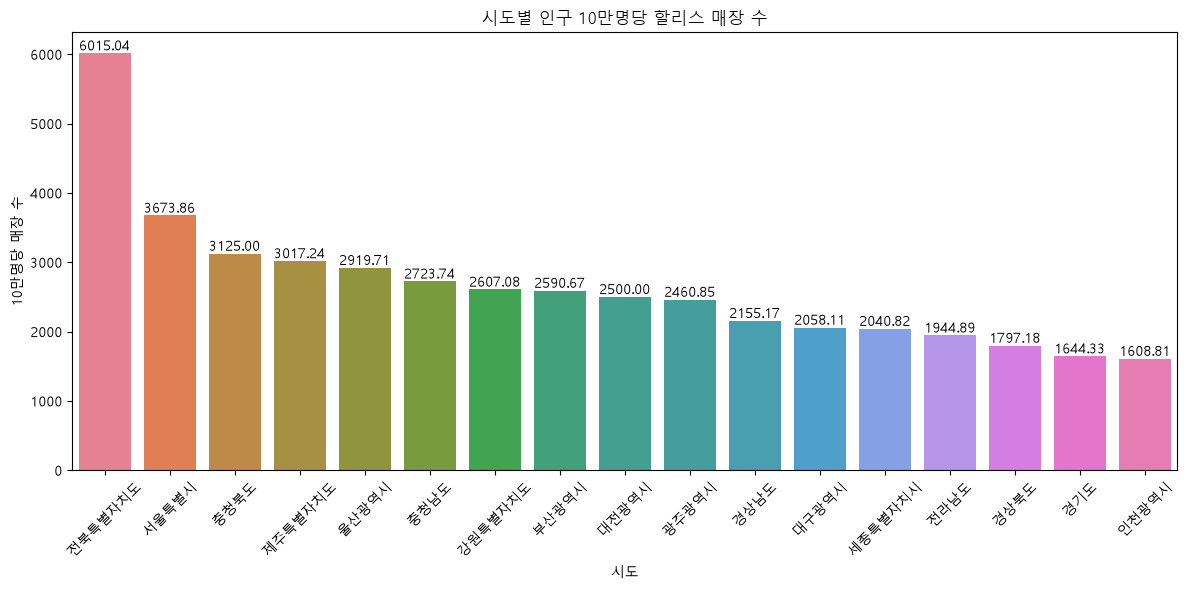

In [66]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns

# 윈도우용 한글 폰트 설정 (하나만 사용)
mpl.rc('font', family='Malgun Gothic')
mpl.rcParams['axes.unicode_minus'] = False

plt.figure(figsize=(12,6))

ax = sns.barplot(
    data=df_merge,
    hue='시도',
    x="시도",
    y="10만명당_매장수"
)

plt.xticks(rotation=45)
plt.title("시도별 인구 10만명당 할리스 매장 수")
plt.xlabel("시도")
plt.ylabel("10만명당 매장 수")

for p in ax.patches:
    ax.text(
        p.get_x() + p.get_width() / 2,
        p.get_height(),
        f"{p.get_height():.2f}",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.tight_layout()
plt.savefig("output/hollys_barplot.png", dpi=200)
plt.show()

할리스는 서울에만 많지 않았다… 인구 대비 매장 밀도 분석 결과

할리스커피 매장은 서울과 수도권에 집중돼 있다는 인식이 강하다. 그러나 매장 수 자체가 아니라 **인구 대비 매장 밀도(10만명당 매장 수)**로 분석하면, 서울보다 더 촘촘하게 분포한 지역이 존재하는 것으로 나타났다.

본 분석은 할리스 공식 홈페이지 매장검색 페이지에서 매장 주소를 수집해 시도별 매장 수를 집계한 뒤, KOSIS 국가통계포털의 시도별 주민등록 인구 데이터와 결합해 **‘인구 10만명당 할리스 매장 수’**를 산출한 결과다.

분석 결과, 전북특별자치도가 인구 10만명당 1.80개로 전국에서 가장 높은 매장 밀도를 기록했다. 이는 2위인 **서울특별시(1.29개)**보다도 큰 수치로, 할리스 매장이 단순히 서울 중심으로만 분포해 있다는 통념과는 다른 결과다.

뒤이어 대전광역시(1.04개), 세종특별자치시(1.02개), 울산광역시(1.01개), **충청북도(1.00개)**가 1개 수준을 유지하며 상위권에 포함됐다. 즉, 일부 광역시 및 중부권 지역에서는 인구 규모가 상대적으로 크지 않더라도 매장 밀도가 높게 형성돼 있음을 확인할 수 있다.

반면 수도권 핵심 지역인 경기도는 0.68개로 중하위권에 그쳤다. 인구가 집중된 지역임에도 매장 밀도가 낮게 나타난 것은, 단순 인구 수만으로 프랜차이즈 입지 전략을 설명하기 어렵다는 점을 보여준다.

중위권에는 강원특별자치도(0.99개), 충청남도(0.94개), 부산광역시(0.93개), 제주특별자치도(0.90개), **광주광역시(0.79개)**가 포함됐다. 특히 광주는 광역시임에도 서울·대전·울산과 비교하면 매장 밀도가 상대적으로 낮은 편이다.

하위권에는 대구광역시(0.72개), 전라남도(0.67개), 경상남도(0.66개), 인천광역시(0.59개), **경상북도(0.56개)**가 위치했다. 인천은 수도권임에도 불구하고 매장 밀도가 전국 최하위권 수준으로 나타났다.


이번 분석은 프랜차이즈 매장 분포를 해석할 때 ‘매장 수’ 자체보다 인구 대비 매장 밀도가 더 중요한 지표가 될 수 있음을 보여준다. 향후 유동인구 데이터나 스타벅스·이디야 등 경쟁 브랜드 매장 데이터까지 결합한다면, 할리스의 입지 전략을 더욱 정밀하게 분석할 수 있을 것으로 보인다.

매장수 vs 인구 관계 (산점도)

findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Fo

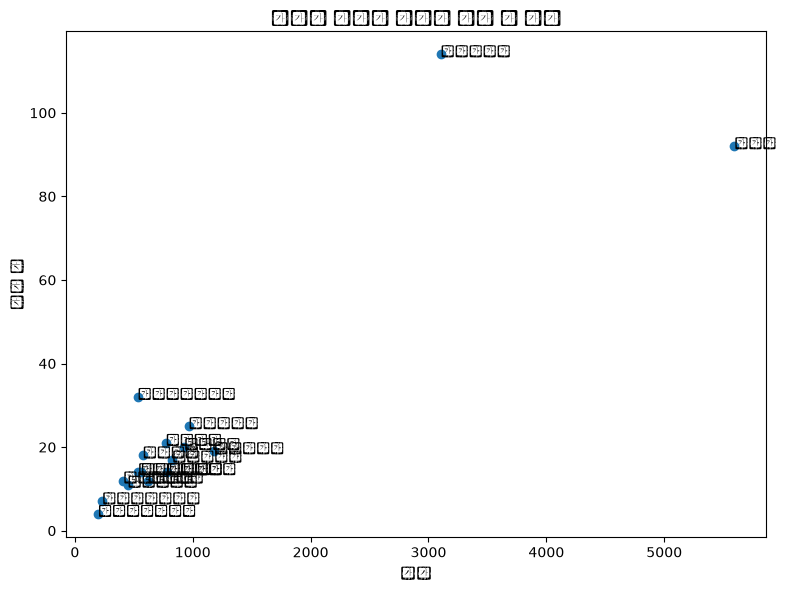

In [59]:
plt.figure(figsize=(8,6))
plt.scatter(df_merge["인구"], df_merge["매장수"])

for i, row in df_merge.iterrows():
    plt.text(row["인구"], row["매장수"], row["시도"], fontsize=9)

plt.title("시도별 인구와 할리스 매장 수 관계")
plt.xlabel("인구")
plt.ylabel("매장 수")
plt.tight_layout()
plt.show()


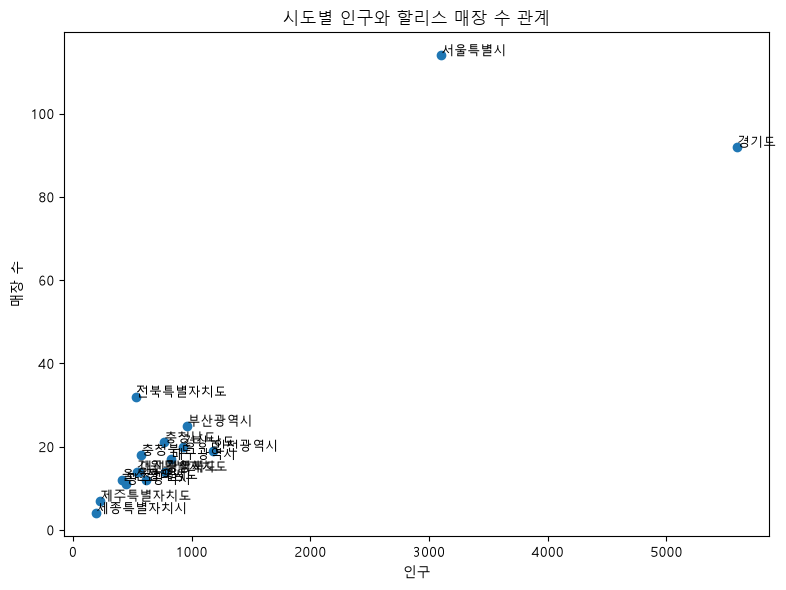

In [67]:
import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rc('font', family='Malgun Gothic')
mpl.rcParams['axes.unicode_minus'] = False

plt.figure(figsize=(8,6))
plt.scatter(df_merge["인구"], df_merge["매장수"])

for i, row in df_merge.iterrows():
    plt.text(row["인구"], row["매장수"], row["시도"], fontsize=9)

plt.title("시도별 인구와 할리스 매장 수 관계")
plt.xlabel("인구")
plt.ylabel("매장 수")
plt.tight_layout()
plt.show()

서울이 아니었다… 산포도가 보여준 ‘할리스 매장 집중’의 진짜 이유

할리스커피 매장은 서울과 수도권에 집중돼 있다는 인식이 강하다. 그러나 시도별 **인구와 할리스 매장 수의 관계를 산포도(Scatter Plot)**로 분석한 결과, 매장 분포는 단순히 인구 규모만으로 설명되지 않는 것으로 나타났다. 인구가 많을수록 매장 수가 증가하는 경향은 분명했지만, 일부 지역은 인구 대비 매장 수가 유독 많거나 적어 뚜렷한 편차를 드러냈다.

이번 분석은 할리스 공식 홈페이지 매장검색 페이지에서 매장 주소를 수집해 시도별 매장 수를 집계한 뒤, 시도별 주민등록 인구 데이터와 결합해 시각화한 것이다. 산포도는 각 시도를 하나의 점으로 표시해, 인구(가로축)가 증가할수록 매장 수(세로축)가 어떻게 변하는지 확인할 수 있도록 구성됐다.

그래프에서 가장 눈에 띄는 지점은 서울특별시와 경기도다. 경기도는 전국에서 가장 많은 인구를 보유한 지역이지만, 매장 수는 서울보다 낮게 나타났다. 반면 서울은 경기도보다 인구 규모가 작음에도 매장 수가 전국 최고 수준으로 표시돼, 인구 대비 매장 집중 현상이 뚜렷했다. 산포도 상에서 서울은 다른 시도들과 비교해 상대적으로 높은 위치에 놓이며, ‘상권 중심형’ 입지 특성이 강하게 나타난 사례로 해석된다.

또한 산포도에서는 다수의 시도가 좌측 하단에 군집을 이루는 형태도 확인된다. 이는 전국 대부분의 시도가 인구와 매장 수에서 비슷한 범위에 분포해 있음을 의미한다. 즉, 할리스 매장 수는 일정 수준까지는 인구 증가에 비례해 증가하지만, 일정 구간 이후에는 상권 구조에 따라 매장 수가 크게 달라질 수 있음을 보여준다.

특히 인구 규모가 크지 않은 일부 지역에서도 매장 수가 상대적으로 높게 나타나며, 산포도에서 평균적인 흐름선보다 위쪽에 위치하는 점들이 확인된다. 이는 해당 지역들이 인구 대비 매장 수가 높다는 뜻이며, ‘인구 중심’이 아닌 ‘상권 중심’ 입점 전략이 작동했을 가능성을 시사한다. 반대로 인구는 많지만 매장 수가 기대 수준보다 낮은 지역들도 존재해, 매장 확장 전략이 지역별로 균일하지 않다는 점을 드러냈다.

이 같은 결과는 프랜차이즈 매장 분포가 단순히 거주 인구만을 따라 움직이는 것이 아니라, 유동인구·오피스 밀집도·역세권 상권·대학가·관광수요 등 복합적인 요인에 의해 결정된다는 점을 뒷받침한다. 실제로 서울은 거주 인구 외에도 전국 최대 규모의 유동인구와 상업시설이 집중돼 있어, 인구 대비 매장 수가 과밀하게 나타날 수 있는 구조를 갖고 있다. 반면 경기도는 인구가 분산돼 있고 생활권이 넓어, 특정 상권에 매장이 집중되기 어려운 환경일 수 있다.

산포도 분석은 단순 순위표보다 더 직접적으로 ‘입지 전략의 비정상적 집중’을 보여준다. 인구가 증가하면 매장 수가 늘어나는 일반적 패턴이 존재함에도, 서울과 같은 특정 지역은 그 패턴에서 벗어나 과도하게 높은 매장 수를 기록했다. 이는 할리스 매장 분포가 인구 기반이 아니라, 상권 중심의 선택적 전략에 의해 강화되고 있음을 시각적으로 확인시켜준다.

이번 분석은 프랜차이즈 입지 전략을 평가할 때 인구와 매장 수의 단순 비교만으로는 부족하며, 산포도 기반의 관계 분석을 통해 ‘예외 지역’과 ‘집중 지역’을 찾아내는 방식이 효과적이라는 점을 보여준다. 향후 유동인구 데이터, 경쟁 브랜드 매장 데이터까지 결합할 경우, 특정 지역의 상권 경쟁 구조와 프랜차이즈 확장 전략을 더욱 정밀하게 분석할 수 있을 것으로 보인다

### 8단계: 지도 시각화(Choropleth)

#### (1) 시도 GeoJSON 확보 방법(실습용)


방법 A (추천)

  - GitHub에서 “korea sido geojson” 검색 후 다운로드
  - https://github.com/southkorea/southkorea-maps/blob/master/gadm/json/skorea-geo.json

대표 키워드:

  - korea administrative boundaries geojson

  - korea sido geojson

다운로드한 파일명을 korea_sido.geojson로 저장

#### (2) Choropleth 지도 코드


In [72]:
import os
print(os.listdir("source"))

['hollys_population_analysis.csv', 'hollys_store.csv', 'hollys_store_geo_kakao_final.csv', 'population_sido.csv', 'skorea-geo.json', '시군구_성_월별_출생_20260730172059.csv', '행정구역_시군구_별__성별_인구수_20260731154417.csv']


In [73]:
import json

with open("source/skorea-geo.json", encoding="utf-8") as f:
    geo = json.load(f)

print(geo["features"][0]["properties"].keys())
print(geo["features"][0]["properties"])

dict_keys(['ID_0', 'ISO', 'NAME_ENGLI', 'NAME_ISO', 'NAME_FAO', 'NAME_LOCAL', 'NAME_OBSOL', 'NAME_VARIA', 'NAME_NONLA', 'NAME_FRENC', 'NAME_SPANI', 'NAME_RUSSI', 'NAME_ARABI', 'NAME_CHINE', 'WASPARTOF', 'CONTAINS', 'SOVEREIGN', 'ISO2', 'WWW', 'FIPS', 'ISON', 'VALIDFR', 'VALIDTO', 'EUmember'])
{'ID_0': 211, 'ISO': 'KOR', 'NAME_ENGLI': 'South Korea', 'NAME_ISO': 'KOREA, REPUBLIC OF', 'NAME_FAO': 'Korea, Republic of', 'NAME_LOCAL': 'Han-guk', 'NAME_OBSOL': None, 'NAME_VARIA': 'Korea, Republic of|Korea, South', 'NAME_NONLA': '????|??', 'NAME_FRENC': 'Corée, République de', 'NAME_SPANI': 'Corea del Sur', 'NAME_RUSSI': '?????, ?????', 'NAME_ARABI': '????? ????????', 'NAME_CHINE': '??, ??', 'WASPARTOF': 'Korea|Chosun|Chosen|Choson|Hanguk', 'CONTAINS': None, 'SOVEREIGN': 'South Korea', 'ISO2': 'KR', 'WWW': None, 'FIPS': 'KS', 'ISON': 410.0, 'VALIDFR': '19530727', 'VALIDTO': 'Present', 'EUmember': 0.0}


In [76]:
import requests

url = "https://raw.githubusercontent.com/southkorea/southkorea-maps/master/kostat/2018/json/skorea-provinces-2018-geo.json"
response = requests.get(url)

with open("source/skorea-provinces-2018-geo.json", "wb") as f:
    f.write(response.content)

print("다운로드 완료")

다운로드 완료


In [77]:
import json

with open("source/skorea-provinces-2018-geo.json", encoding="utf-8") as f:
    geo = json.load(f)

print(geo["features"][0]["properties"])
print(len(geo["features"]))   # 17개 안팎(시도 개수)이어야 정상

{'name': '서울특별시', 'base_year': '2018', 'name_eng': 'Seoul', 'code': '11'}
17


In [78]:
import json
import folium
import pandas as pd
import os

df = pd.read_csv("output/hollys_report.csv")

with open("source/skorea-provinces-2018-geo.json", encoding="utf-8") as f:
    geo = json.load(f)

# GeoJSON은 2018년 기준이라 개편 전 지명을 쓴다. 현재 지명으로 맞춘다.
name_fix = {"강원도": "강원특별자치도", "전라북도": "전북특별자치도"}
for feat in geo["features"]:
    n = feat["properties"]["name"]
    feat["properties"]["name"] = name_fix.get(n, n)

os.makedirs("output", exist_ok=True)

m = folium.Map(location=[35.9, 127.8], zoom_start=7)   # 전국이 보이도록 중심 조정

folium.Choropleth(
    geo_data=geo,
    data=df,
    columns=["시도", "10만명당_매장수"],
    key_on="feature.properties.name",
    fill_color="YlOrRd",
    fill_opacity=0.7,
    line_opacity=0.3,
    legend_name="10만명당 할리스 매장 수"
).add_to(m)

m.save("output/hollys_density_map.html")
print("저장 완료: output/hollys_density_map.html")


저장 완료: output/hollys_density_map.html


In [80]:
import json
import folium
import pandas as pd
import os

df = pd.read_csv("output/hollys_report.csv")

# 반드시 이 파일명으로 (skorea-geo.json 아님!)
with open("source/skorea-provinces-2018-geo.json", encoding="utf-8") as f:
    geo = json.load(f)

name_fix = {"강원도": "강원특별자치도", "전라북도": "전북특별자치도"}
for feat in geo["features"]:
    n = feat["properties"]["name"]
    feat["properties"]["name"] = name_fix.get(n, n)

os.makedirs("output", exist_ok=True)

m = folium.Map(location=[35.9, 127.8], zoom_start=7)

folium.Choropleth(
    geo_data=geo,
    data=df,
    columns=["시도", "10만명당_매장수"],
    key_on="feature.properties.name",
    fill_color="YlOrRd",
    fill_opacity=0.7,
    line_opacity=0.3,
    legend_name="10만명당 할리스 매장 수"
).add_to(m)

m.save("output/hollys_density_map.html")
print("저장 완료: output/hollys_density_map.html")

저장 완료: output/hollys_density_map.html


In [81]:
# import folium
# import json
# import pandas as pd

df = pd.read_csv("source/hollys_population_analysis.csv")

with open("source/skorea-provinces-2018-geo.json", encoding="utf-8") as f:
    geo = json.load(f)

# 광주광역시의 중심 기준 위도·경도
m = folium.Map(location=[35.1595, 126.8526], zoom_start=7)

folium.Choropleth(
    geo_data=geo,
    data=df,
    columns=["시도", "10만명당_매장수"],
    key_on="feature.properties.name",
    fill_opacity=0.7,
    line_opacity=0.3,
    legend_name="10만명당 할리스 매장 수"
).add_to(m)

m.save("output/hollys_density_map.html")
print("저장 완료: output/hollys_density_map.html")


저장 완료: output/hollys_density_map.html


In [82]:
### “광주광역시만” 확대 분석
df = pd.read_csv("source/hollys_store_geo_kakao_final.csv")


df_gwangju = df[df["시도"].str.contains("광주광역시")].dropna(subset=["위도", "경도"])


m = folium.Map(location=[35.13, 126.83], zoom_start=12)


for _, row in df_gwangju.iterrows():
    tooltip_text = f"""
    매장명: {row['매장명']}<br>
    주소: {row['주소']}<br>
    전화번호: {row['전화번호']}
    """


    popup_text = f"""
    <b>매장명:</b> {row['매장명']}<br>
    <b>주소:</b> {row['주소']}<br>
    <b>전화번호:</b> {row['전화번호']}
    """


    folium.CircleMarker(
        location=[row["위도"], row["경도"]],
        radius=5,
        popup=folium.Popup(popup_text, max_width=300),
        tooltip=folium.Tooltip(tooltip_text),
        fill=True,
        fill_opacity=0.7
    ).add_to(m)


m.save("output/hollys_gwangju_map.html")
print("저장 완료: output/hollys_gwangju_map.html")




저장 완료: output/hollys_gwangju_map.html


In [83]:
import folium
import json
import pandas as pd
from folium.plugins import MarkerCluster

# 1) 시도별 밀도 데이터
df = pd.read_csv("source/hollys_population_analysis.csv")

with open("source/skorea-provinces-2018-geo.json", encoding="utf-8") as f:
    geo = json.load(f)

name_fix = {"강원도": "강원특별자치도", "전라북도": "전북특별자치도"}
for feat in geo["features"]:
    n = feat["properties"]["name"]
    feat["properties"]["name"] = name_fix.get(n, n)

# 2) 전국이 보이도록 중심좌표 설정
m = folium.Map(location=[35.9, 127.8], zoom_start=7)

# 3) 시도별 Choropleth
folium.Choropleth(
    geo_data=geo,
    data=df,
    columns=["시도", "10만명당_매장수"],
    key_on="feature.properties.name",
    fill_color="YlOrRd",        # 누락되어 있던 부분
    fill_opacity=0.7,
    line_opacity=0.3,
    legend_name="10만명당 할리스 매장 수"
).add_to(m)

# 4) 전국 매장 개별 마커 (위경도 있는 매장 전체)
df_store = pd.read_csv("source/hollys_store_geo_kakao_final.csv")
df_store = df_store.dropna(subset=["위도", "경도"])

cluster = MarkerCluster(name="할리스 매장").add_to(m)
for _, row in df_store.iterrows():
    folium.CircleMarker(
        location=[row["위도"], row["경도"]],
        radius=3,
        popup=row["매장명"],
        color="#8B4513",
        fill=True,
        fill_opacity=0.8,
    ).add_to(cluster)

folium.LayerControl().add_to(m)

m.save("output/hollys_density_map.html")
print("저장 완료: output/hollys_density_map.html")

저장 완료: output/hollys_density_map.html
